---

ใช้ชุดข้อมูล "number_hand_writting.csv"
  
ซึ่งเป็นข้อมูลที่แปลงมาจากภาพลายมือการเขียนเลข 0 - 9 โดยมีรายละเอียดของแต่ละคอลัมน์ดังนี้    
F1-F64: ความเข้มของลายมือในแต่ละช่อง โดย 1 ภาพลายมือจะเป็นตาราง 8x8 = 64 ช่อง ในแต่ละช่องความเข้มจะมีค่า 0-16  
Class:  label ว่าข้อมูลแถวนั้นเป็นเลขอะไร  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics


df_handw = pd.read_csv("https://raw.githubusercontent.com/ThammakornS/ProgStat/main/dataset/number_hand_writting.csv")
df_handw.head()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F56,F57,F58,F59,F60,F61,F62,F63,F64,Class
0,0,1,6,15,12,1,0,0,0,7,...,0,0,0,6,14,7,1,0,0,0
1,0,0,10,16,6,0,0,0,0,7,...,0,0,0,10,16,15,3,0,0,0
2,0,0,8,15,16,13,0,0,0,1,...,0,0,0,9,14,0,0,0,0,7
3,0,0,0,3,11,16,0,0,0,0,...,0,0,0,0,1,15,2,0,0,4
4,0,0,5,14,4,0,0,0,0,0,...,0,0,0,4,12,14,7,0,0,6


<Axes: >

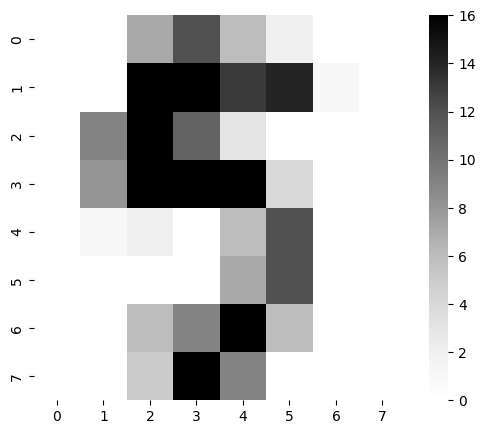

In [ ]:
dat5 = df_handw.loc[13, 'F1':'F64'].values.reshape(8,8)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(dat5, cmap='Greys', ax=ax)


1. (20 คะแนน) ให้เลือกใช้ SVM หรือ ANN ในการสร้างโมเดลเพื่อทำนายว่าเป็นตัวเลขใดจากข้อมูลลายมือ โดยมีรายละเอียดดังนี้  
- ให้ 'Class' เป็นข้อมูล outcome (y) และ 'F1' - 'F64' เป็นข้อมูล feature (X)  
- มีการแบ่งข้อมูลเป็น training set และ test set โดยใช้ train_test_split ซึ่งมี argument test_size=0.3 และ random_state=1234
- สร้างโมเดลจากข้อมูล training set ต้องทำ k-fold cross-validation เพื่อทำการ optimize parameter โดยให้เลือก parameter ที่จะทำการ optimize ตามความเหมาะสม (อย่างน้อย 1 parameter)
    - สำหรับ SVM สามารถทำการ optimize: kernel, C, gamma, etc.
    - สำหรับ ANN สามารถทำการ optimize: hidden_layer_sizes, activation, solver, learning_rate_initfloat, learning_rate, etc.
    - การทำ k-fold cross-validation ให้ใช้ StratifiedKFold โดย n_splits=5, shuffle=True, และ random_state=1234
- สร้างโมเดลสุดท้ายจาก prameter ที่ optimize ได้ แล้วนำไปทดสอบประสิทธิภาพในการทำนาย 'Class' ของ test set โดยประสิทธิภาพการทำนายที่วัดคือ accuracy
- แสดง confusion matrix ที่ได้จากการทำนาย 'Class' ของ test set พร้อมทั้งแสดง accuracy ที่ได้

In [ ]:
#Your code

In [ ]:
X = df_handw.loc[:,~(df_handw.columns=='Class')]
y = df_handw.Class

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=0)

\
Reset all indices to start from 0 to avoid further confusion.

In [ ]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

\
Set structures of hidden to be tested:

In [ ]:
layers = {'config1':(128, 64, 32),
          'config2':(128, 64, 32, 16),
          'config3':(128, 64, 32, 16, 8)}
for k,v in layers.items():
    print(v)

(128, 64, 32)
(128, 64, 32, 16)
(128, 64, 32, 16, 8)


\
Configure cv:

In [ ]:
skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=1234)

\
Perform cv for each hidden layer configuration:

In [ ]:
perf = {}
perf['hidden_conf'] = []
perf['acc'] = []

for k,v in layers.items():
    model_ann = MLPClassifier(hidden_layer_sizes=v,
                              activation='relu',
                              solver='adam',
                              random_state=1234, # random number generation for weights and bias initialization
                              learning_rate='adaptive'
                              )

    # predict class
    y_pred = cross_val_predict(estimator=model_ann,
                               X=X_train,
                               y=y_train,
                               cv=skf)
    acc = metrics.accuracy_score(y_train, y_pred)

    perf['hidden_conf'].append(k)
    perf['acc'].append(acc)

perf = pd.DataFrame(perf)
perf.sort_values(by='acc', ascending=False)

,hidden_conf,acc
0,config1,0.980681
1,config2,0.978139
2,config3,0.973564


\
If we focus on auc, then we select config1

###
#### <span style="color:#166e20">*Use the ANN model with selected hidden layer structure to predict test set*</span>

\
Create an ANN model using selected hidden layer structure from the previous step and fit model on train data.

In [ ]:
ann = MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                    activation='relu',
                    solver='adam',
                    random_state=1234, # random number generation for weights and bias initialization
                    learning_rate='adaptive')
ann.fit(X=X_train, y=y_train)

MLPClassifier(hidden_layer_sizes=(128, 64, 32), learning_rate='adaptive',
              random_state=1234)

\
Use above ANN model to predict test set

In [ ]:
y_pred_test = ann.predict(X_test)
y_pred_test

array([3, 8, 3, ..., 5, 7, 7])

\
Display confusion matrix

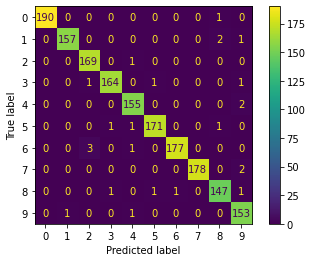

In [ ]:
conf_mat = metrics.confusion_matrix(y_test, y_pred_test, labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
metrics.ConfusionMatrixDisplay(conf_mat,
                               display_labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]).plot()

\
Evaluate model performance scores based on test set

In [ ]:
acc = metrics.accuracy_score(y_test, y_pred_test)

print(f"Test set performance scores:\n"
      f"accuracy: {acc:.2f}\n"
     )

Test set performance scores:
accuracy: 0.99



---

---